# ProdiRank WP1 — ADMET / drug-likeness screening

Cleaned/debugged notebook version of `wp1_admet_screen.py`.

**Input:** `04_ProdiRank_Workflow/01_data_intake_cleaning/outputs/compound_manifest_clean.csv`

**Outputs:** written to `04_ProdiRank_Workflow/02_cheminformatics/outputs/`.

ADMET/PAINS/Brenk flags are prioritization warnings, not experimental evidence of toxicity or safety.


In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, QED
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

RDLogger.DisableLog("rdApp.*")

print("Python:", sys.version.split()[0])
print("RDKit import: OK")


Python: 3.11.16
RDKit import: OK


## 1. Project paths

In [2]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    markers = [
        "04_ProdiRank_Workflow",
        "01_Brian_Manuscript_and_Chemistry",
        "03_Public_Data_CellMiner_NCI60",
    ]
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise FileNotFoundError(
        "Could not find ProdiRank project root. "
        "Run this notebook from inside ARINBRE_Prodiginine_ProdiRank or edit PROJECT_ROOT manually."
    )

PROJECT_ROOT = find_project_root()

DATA_INTAKE_OUT = PROJECT_ROOT / "04_ProdiRank_Workflow" / "01_data_intake_cleaning" / "outputs"
CHEM_OUT = PROJECT_ROOT / "04_ProdiRank_Workflow" / "02_cheminformatics" / "outputs"
FIG_DIR = CHEM_OUT / "figures"

CHEM_OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST = DATA_INTAKE_OUT / "compound_manifest_clean.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MANIFEST    :", MANIFEST)
print("CHEM_OUT    :", CHEM_OUT)
print("FIG_DIR     :", FIG_DIR)

if not MANIFEST.exists():
    raise FileNotFoundError(f"Missing compound manifest: {MANIFEST}")


PROJECT_ROOT: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank
MANIFEST    : /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/01_data_intake_cleaning/outputs/compound_manifest_clean.csv
CHEM_OUT    : /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs
FIG_DIR     : /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/figures


## 2. Reference compounds

The original script had a useful reference validation gate, but its embedded reference SMILES were internally inconsistent with its own expected molecular formulas. This notebook uses corrected reference SMILES that reproduce the expected formulas/MW:

- Prodigiosin: `C20H25N3O`
- Obatoclax/GX15-070: `C20H19N3O`

Keep reference validation on. Before manuscript submission, manually record the exact PubChem/ChEMBL/IUPHAR source/version in the audit file.


In [3]:
REFERENCES = [
    {
        "name": "Prodigiosin (natural)",
        "smiles": "CCCCCc3cc(=Cc2[nH]c(c1ccc[nH]1)cc2OC)nc3C",
        "class": "ref_natural",
        "reference_note": "Verify exact reference source before publication",
    },
    {
        "name": "Obatoclax (GX15-070)",
        "smiles": "COc1c/c(=C\\2/C=c3c(=N2)cccc3)/[nH]/c/1=C\\c1[nH]c(C)cc1C",
        "class": "ref_clinical",
        "reference_note": "Verify exact reference source before publication",
    },
]

REFERENCE_TRUTH = {
    "Prodigiosin (natural)": {
        "formula": "C20H25N3O",
        "MW": 323.4,
        "MW_tol": 1.0,
    },
    "Obatoclax (GX15-070)": {
        "formula": "C20H19N3O",
        "MW": 317.4,
        "MW_tol": 1.0,
    },
}

STRICT_REFERENCE_VALIDATION = True


## 3. Load cleaned manifest and build auditable ADMET input table

In [4]:
manifest = pd.read_csv(MANIFEST)

required = {"compound_id", "smiles_clean", "smiles_valid"}
missing = sorted(required - set(manifest.columns))
if missing:
    raise ValueError(f"Manifest missing required columns: {missing}")

manifest = manifest[manifest["smiles_valid"].astype(str).str.lower().isin(["true", "1", "yes"])].copy()

def assign_class(cid):
    cid = str(cid)
    if cid.startswith("JP-Cmpd"):
        return "target"
    if cid.startswith("BW-II"):
        return "made"
    if cid.startswith("Proposed"):
        return "proposed"
    return "other"

admet_input = manifest.assign(
    name=manifest["compound_id"],
    smiles=manifest["smiles_clean"],
    **{"class": manifest["compound_id"].map(assign_class)}
)[["name", "smiles", "class", "compound_id", "paper_id", "source_section", "needs_manual_review"]].copy()

ref_df = pd.DataFrame(REFERENCES)
ref_df["compound_id"] = ref_df["name"]
ref_df["paper_id"] = ""
ref_df["source_section"] = "Reference compounds"
ref_df["needs_manual_review"] = True

admet_input = pd.concat([
    admet_input,
    ref_df[["name", "smiles", "class", "compound_id", "paper_id", "source_section", "needs_manual_review"]],
], ignore_index=True)

admet_input = admet_input.drop_duplicates(subset=["name"], keep="first").reset_index(drop=True)

admet_input_path = CHEM_OUT / "wp1_admet_input_table.csv"
admet_input.to_csv(admet_input_path, index=False)

print(f"Compounds to screen: {len(admet_input)}")
print(f"Wrote: {admet_input_path}")
display(admet_input)


Compounds to screen: 15
Wrote: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_admet_input_table.csv


,name,smiles,class,compound_id,paper_id,source_section,needs_manual_review
0,BW-II-1,COC1=CC(c2ccc[nH]2)=N/C1=C\c1[nH]c(-c2ccc[nH]2...,made,BW-II-1,NaN,Compounds made and tested by UAMS,False
1,BW-II-103,c1c[nH]c(-c2nc3ccccc3s2)c1,made,BW-II-103,NaN,Compounds made and tested by UAMS,False
2,BW-II-106,Clc1ccc2sc(-c3ccc[nH]3)nc2c1,made,BW-II-106,NaN,Compounds made and tested by UAMS,False
3,BW-II-110,COc1ccc2nc(-c3ccc[nH]3)sc2c1,made,BW-II-110,NaN,Compounds made and tested by UAMS,False
4,Proposed-benzothiazole-001,COc1cc(-c2ccc[nH]2)[nH]c1-c1nc2ccccc2s1,proposed,Proposed-benzothiazole-001,NaN,Proposed Unnatural prodigiosin analogs as anti...,True
5,JP-Cmpd-6,COC1=CC(c2nc3ccccc3s2)=N/C1=C\c1ccc[nH]1,target,JP-Cmpd-6,JP-Cmpd-6,Proposed Unnatural prodigiosin analogs as anti...,False
6,JP-Cmpd-10,COC1=CC(c2ccc[nH]2)=N/C1=C\c1nc2ccccc2s1,target,JP-Cmpd-10,JP-Cmpd-10,Proposed Unnatural prodigiosin analogs as anti...,False
7,Proposed-benzothiazole-002,CCCc1ccc2nc(-c3[nH]c(-c4ccc[nH]4)cc3OC)sc2c1,proposed,Proposed-benzothiazole-002,NaN,Proposed Unnatural prodigiosin analogs as anti...,True
8,Proposed-benzothiazole-003,COc1cc(-c2ccc[nH]2)[nH]c1-c1nc2c(C)ccc(C)c2s1,proposed,Proposed-benzothiazole-003,NaN,Proposed Unnatural prodigiosin analogs as anti...,True
9,Proposed-benzothiazole-004,COc1ccc2nc(-c3[nH]c(-c4ccc[nH]4)cc3OC)sc2c1,proposed,Proposed-benzothiazole-004,NaN,Proposed Unnatural prodigiosin analogs as anti...,True


## 4. RDKit catalogs and drug-likeness rules

In [5]:
def make_catalog(*catalog_enums):
    params = FilterCatalogParams()
    for c in catalog_enums:
        params.AddCatalog(c)
    return FilterCatalog(params)

FC = FilterCatalogParams.FilterCatalogs
PAINS_CAT = make_catalog(FC.PAINS_A, FC.PAINS_B, FC.PAINS_C)
BRENK_CAT = make_catalog(FC.BRENK)

def alert_hits(mol, catalog):
    return [m.GetDescription() for m in catalog.GetMatches(mol)]

def lipinski(d):
    violations = sum([d["MW"] > 500, d["cLogP"] > 5, d["HBD"] > 5, d["HBA"] > 10])
    return violations, violations <= 1

def veber(d):
    return d["RotB"] <= 10 and d["TPSA"] <= 140

def ghose(d):
    return (
        160 <= d["MW"] <= 480
        and -0.4 <= d["cLogP"] <= 5.6
        and 40 <= d["MolMR"] <= 130
        and 20 <= d["HeavyAtoms"] <= 70
    )

def egan(d):
    return d["TPSA"] <= 131.6 and d["cLogP"] <= 5.88


## 5. Descriptor calculation

In [6]:
def screen_compound(name, smiles, cls):
    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES for {name!r}: {smiles!r}")

    d = {
        "name": name,
        "class": cls,
        "smiles": Chem.MolToSmiles(mol),
        "formula": rdMolDescriptors.CalcMolFormula(mol),
        "MW": Descriptors.MolWt(mol),
        "ExactMW": Descriptors.ExactMolWt(mol),
        "cLogP": Crippen.MolLogP(mol),
        "MolMR": Crippen.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotB": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "QED": QED.qed(mol),
    }

    n_viol, ro5_pass = lipinski(d)
    pains = alert_hits(mol, PAINS_CAT)
    brenk = alert_hits(mol, BRENK_CAT)

    d.update({
        "Ro5_violations": int(n_viol),
        "Ro5_pass": bool(ro5_pass),
        "Veber_pass": bool(veber(d)),
        "Ghose_pass": bool(ghose(d)),
        "Egan_pass": bool(egan(d)),
        "PAINS_clean": len(pains) == 0,
        "Brenk_clean": len(brenk) == 0,
        "PAINS_alerts": "; ".join(pains),
        "Brenk_alerts": "; ".join(brenk),
        "n_PAINS_alerts": len(pains),
        "n_Brenk_alerts": len(brenk),
    })
    return d

admet_rows = []
for _, r in admet_input.iterrows():
    admet_rows.append(screen_compound(r["name"], r["smiles"], r["class"]))

admet = pd.DataFrame(admet_rows)

meta_cols = ["name", "compound_id", "paper_id", "source_section", "needs_manual_review"]
admet = admet.merge(admet_input[meta_cols], on="name", how="left")

print(f"Descriptors computed: {len(admet)}")
display(admet.head())


Descriptors computed: 15


,name,class,smiles,formula,MW,ExactMW,cLogP,MolMR,TPSA,HBD,...,PAINS_clean,Brenk_clean,PAINS_alerts,Brenk_alerts,n_PAINS_alerts,n_Brenk_alerts,compound_id,paper_id,source_section,needs_manual_review
0,BW-II-1,made,COC1=CC(c2ccc[nH]2)=N/C1=C\c1[nH]c(-c2ccc[nH]2...,C19H18N4O2,334.379,334.142976,3.7206,97.5301,78.19,3,...,True,True,,,0,0,BW-II-1,NaN,Compounds made and tested by UAMS,False
1,BW-II-103,made,c1c[nH]c(-c2nc3ccccc3s2)c1,C11H8N2S,200.266,200.040819,3.2914,59.4067,28.68,1,...,True,True,,,0,0,BW-II-103,NaN,Compounds made and tested by UAMS,False
2,BW-II-106,made,Clc1ccc2sc(-c3ccc[nH]3)nc2c1,C11H7ClN2S,234.711,234.001847,3.9448,64.4167,28.68,1,...,True,True,,,0,0,BW-II-106,NaN,Compounds made and tested by UAMS,False
3,BW-II-110,made,COc1ccc2nc(-c3ccc[nH]3)sc2c1,C12H10N2OS,230.292,230.051384,3.3000,65.9587,37.91,1,...,True,True,,,0,0,BW-II-110,NaN,Compounds made and tested by UAMS,False
4,Proposed-benzothiazole-001,proposed,COc1cc(-c2ccc[nH]2)[nH]c1-c1nc2ccccc2s1,C16H13N3OS,295.367,295.077933,4.2951,85.7454,53.70,2,...,True,True,,,0,0,Proposed-benzothiazole-001,NaN,Proposed Unnatural prodigiosin analogs as anti...,True


## 6. Reference validation and write descriptor table

In [7]:
def validate_references(df, strict=True):
    problems = []
    checked = []
    for _, r in df.iterrows():
        truth = REFERENCE_TRUTH.get(r["name"])
        if not truth:
            continue
        checked.append(r["name"])
        if r["formula"] != truth["formula"]:
            problems.append(f"{r['name']}: formula {r['formula']} != expected {truth['formula']}")
        if abs(float(r["MW"]) - float(truth["MW"])) > float(truth["MW_tol"]):
            problems.append(f"{r['name']}: MW {r['MW']:.2f} != expected ~{truth['MW']:.1f}")

    if problems:
        print("*** REFERENCE VALIDATION FAILED ***")
        for p in problems:
            print(" -", p)
        if strict:
            raise ValueError("Reference validation failed. Fix reference SMILES before using figures.")
    else:
        print("Reference validation: OK")
        print("Checked:", ", ".join(checked))

validate_references(admet, strict=STRICT_REFERENCE_VALIDATION)

desc_path = CHEM_OUT / "wp1_admet_descriptors.csv"
xlsx_path = CHEM_OUT / "wp1_admet_descriptors.xlsx"
admet.to_csv(desc_path, index=False)
admet.to_excel(xlsx_path, index=False)

print(f"Wrote: {desc_path}")
print(f"Wrote: {xlsx_path}")

display_cols = [
    "name", "class", "formula", "MW", "cLogP", "TPSA", "HBD", "HBA", "RotB", "QED",
    "Ro5_pass", "Veber_pass", "Ghose_pass", "Egan_pass", "PAINS_clean", "Brenk_clean",
    "Ro5_violations", "n_PAINS_alerts", "n_Brenk_alerts"
]
display(admet[display_cols])


Reference validation: OK
Checked: Prodigiosin (natural), Obatoclax (GX15-070)
Wrote: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_admet_descriptors.csv
Wrote: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_admet_descriptors.xlsx


,name,class,formula,MW,cLogP,TPSA,HBD,HBA,RotB,QED,Ro5_pass,Veber_pass,Ghose_pass,Egan_pass,PAINS_clean,Brenk_clean,Ro5_violations,n_PAINS_alerts,n_Brenk_alerts
0,BW-II-1,made,C19H18N4O2,334.379,3.72060,78.19,3,3,5,0.664765,True,True,True,True,True,True,0,0,0
1,BW-II-103,made,C11H8N2S,200.266,3.29140,28.68,1,2,1,0.641182,True,True,False,True,True,True,0,0,0
2,BW-II-106,made,C11H7ClN2S,234.711,3.94480,28.68,1,2,1,0.678802,True,True,False,True,True,True,0,0,0
3,BW-II-110,made,C12H10N2OS,230.292,3.30000,37.91,1,3,2,0.733114,True,True,False,True,True,True,0,0,0
4,Proposed-benzothiazole-001,proposed,C16H13N3OS,295.367,4.29510,53.70,2,3,3,0.591965,True,True,True,True,True,True,0,0,0
5,JP-Cmpd-6,target,C17H13N3OS,307.378,3.99850,50.27,1,4,3,0.794876,True,True,True,True,True,True,0,0,0
6,JP-Cmpd-10,target,C17H13N3OS,307.378,3.99850,50.27,1,4,3,0.794876,True,True,True,True,True,True,0,0,0
7,Proposed-benzothiazole-002,proposed,C19H19N3OS,337.448,5.24760,53.70,2,3,5,0.522556,True,True,True,True,True,True,1,0,0
8,Proposed-benzothiazole-003,proposed,C18H17N3OS,323.421,4.91194,53.70,2,3,3,0.562514,True,True,True,True,True,True,0,0,0
9,Proposed-benzothiazole-004,proposed,C17H15N3O2S,325.393,4.30370,62.93,2,4,4,0.587714,True,True,True,True,True,True,0,0,0


## 7. Flag audit

In [8]:
print("--- flags ---")
for _, r in admet.iterrows():
    flags = []
    if not r.Ro5_pass:
        flags.append(f"Ro5({int(r.Ro5_violations)} viol.)")
    if not r.Veber_pass:
        flags.append("Veber")
    if not r.Ghose_pass:
        flags.append("Ghose")
    if not r.Egan_pass:
        flags.append("Egan")
    if r.PAINS_alerts:
        flags.append(f"PAINS[{r.PAINS_alerts}]")
    if r.Brenk_alerts:
        flags.append(f"Brenk[{r.Brenk_alerts}]")

    print(
        f"{r['name']:<32} MW={r.MW:6.1f}  cLogP={r.cLogP:5.2f}  "
        f"TPSA={r.TPSA:5.1f}  QED={r.QED:.2f}  "
        f"{'; '.join(flags) if flags else 'no flags'}"
    )


--- flags ---
BW-II-1                          MW= 334.4  cLogP= 3.72  TPSA= 78.2  QED=0.66  no flags
BW-II-103                        MW= 200.3  cLogP= 3.29  TPSA= 28.7  QED=0.64  Ghose
BW-II-106                        MW= 234.7  cLogP= 3.94  TPSA= 28.7  QED=0.68  Ghose
BW-II-110                        MW= 230.3  cLogP= 3.30  TPSA= 37.9  QED=0.73  Ghose
Proposed-benzothiazole-001       MW= 295.4  cLogP= 4.30  TPSA= 53.7  QED=0.59  no flags
JP-Cmpd-6                        MW= 307.4  cLogP= 4.00  TPSA= 50.3  QED=0.79  no flags
JP-Cmpd-10                       MW= 307.4  cLogP= 4.00  TPSA= 50.3  QED=0.79  no flags
Proposed-benzothiazole-002       MW= 337.4  cLogP= 5.25  TPSA= 53.7  QED=0.52  no flags
Proposed-benzothiazole-003       MW= 323.4  cLogP= 4.91  TPSA= 53.7  QED=0.56  no flags
Proposed-benzothiazole-004       MW= 325.4  cLogP= 4.30  TPSA= 62.9  QED=0.59  no flags
Proposed-benzothiazole-005       MW= 329.8  cLogP= 4.95  TPSA= 53.7  QED=0.56  no flags
Proposed-benzothiazole-006 

## 8. Make traffic-light figure

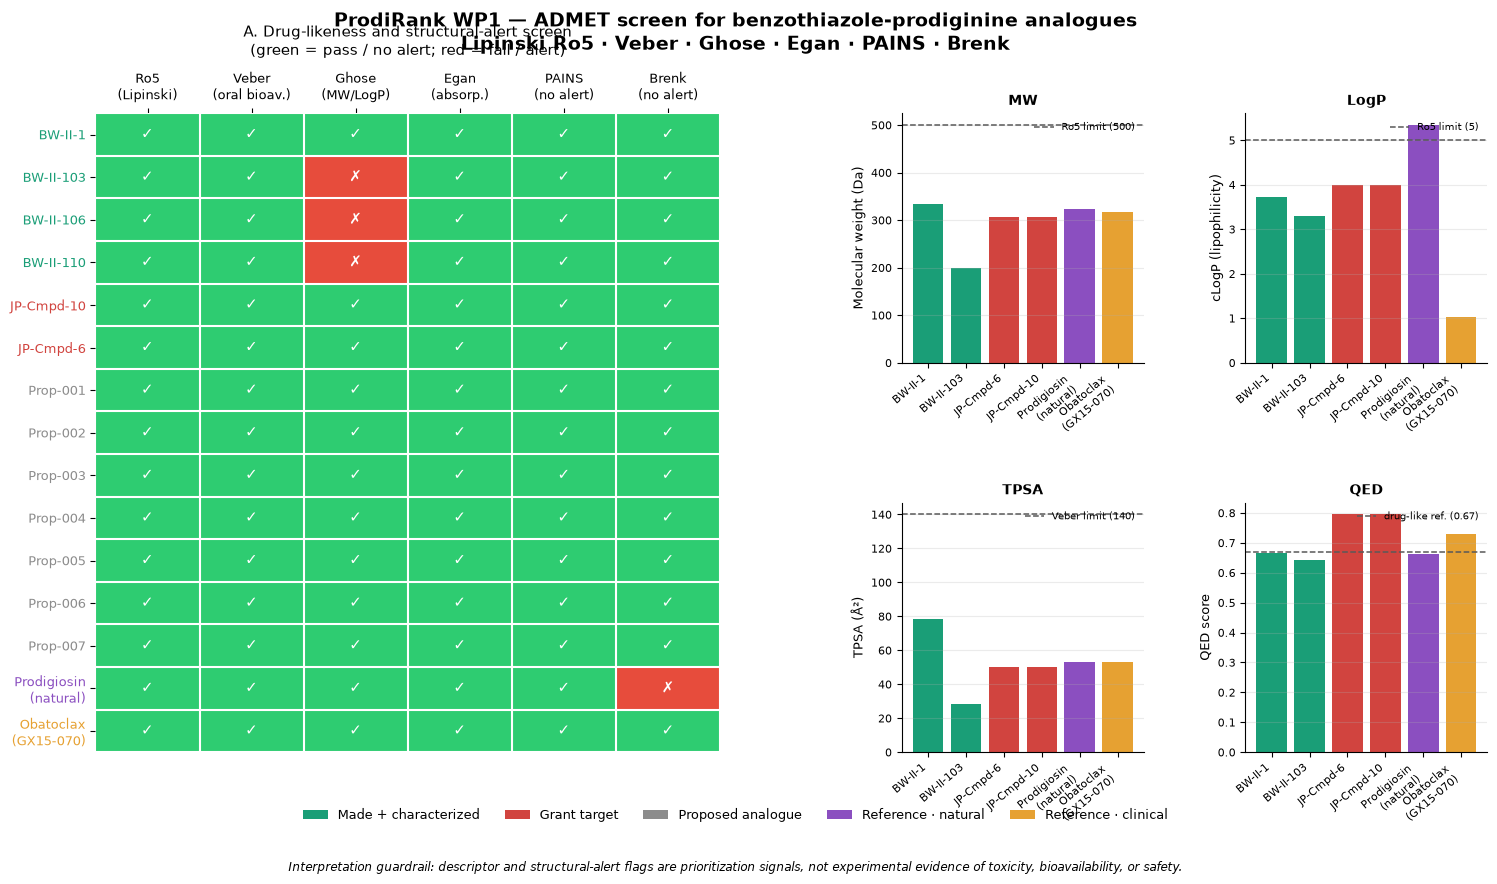

Wrote: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/figures/wp1_admet_trafficlight.pdf
Wrote: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/figures/wp1_admet_trafficlight.png


In [9]:
CLASS_COLOR = {
    "made": "#1a9e77",
    "target": "#d1443f",
    "proposed": "#8c8c8c",
    "ref_natural": "#8b4fc0",
    "ref_clinical": "#e6a132",
    "other": "#555555",
}
CLASS_LABEL = {
    "made": "Made + characterized",
    "target": "Grant target",
    "proposed": "Proposed analogue",
    "ref_natural": "Reference · natural",
    "ref_clinical": "Reference · clinical",
    "other": "Other",
}

RULE_COLS = ["Ro5_pass", "Veber_pass", "Ghose_pass", "Egan_pass", "PAINS_clean", "Brenk_clean"]
RULE_LABELS = [
    "Ro5\n(Lipinski)",
    "Veber\n(oral bioav.)",
    "Ghose\n(MW/LogP)",
    "Egan\n(absorp.)",
    "PAINS\n(no alert)",
    "Brenk\n(no alert)",
]

PASS_C, FAIL_C = "#2ecc71", "#e74c3c"

def short_name(x):
    return (
        str(x)
        .replace("Proposed-benzothiazole-", "Prop-")
        .replace("Prodigiosin (natural)", "Prodigiosin\n(natural)")
        .replace("Obatoclax (GX15-070)", "Obatoclax\n(GX15-070)")
    )

def make_figure(df, outstem):
    class_order = {"made": 0, "target": 1, "proposed": 2, "ref_natural": 3, "ref_clinical": 4, "other": 5}
    plot_df = df.copy()
    plot_df["_class_order"] = plot_df["class"].map(class_order).fillna(99)
    plot_df = plot_df.sort_values(["_class_order", "name"]).reset_index(drop=True)

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=[1.12, 1.05],
        hspace=0.56,
        wspace=0.30,
        left=0.10,
        right=0.97,
        top=0.86,
        bottom=0.15,
    )

    axA = fig.add_subplot(gs[:, 0])
    M = plot_df[RULE_COLS].to_numpy(dtype=bool)
    cmap = mcolors.ListedColormap([FAIL_C, PASS_C])
    axA.imshow(np.where(M, 1, 0), cmap=cmap, vmin=0, vmax=1, aspect="auto")

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            axA.text(j, i, "✓" if M[i, j] else "✗",
                     ha="center", va="center", color="white", fontsize=11, fontweight="bold")

    axA.set_xticks(range(len(RULE_LABELS)))
    axA.set_xticklabels(RULE_LABELS, fontsize=9)
    axA.xaxis.set_ticks_position("top")

    axA.set_yticks(range(len(plot_df)))
    axA.set_yticklabels([short_name(x) for x in plot_df["name"]], fontsize=9)
    for tick, cls in zip(axA.get_yticklabels(), plot_df["class"]):
        tick.set_color(CLASS_COLOR.get(cls, "black"))

    axA.set_xticks(np.arange(-0.5, len(RULE_LABELS), 1), minor=True)
    axA.set_yticks(np.arange(-0.5, len(plot_df), 1), minor=True)
    axA.grid(which="minor", color="white", linewidth=1.5)
    axA.tick_params(which="minor", length=0)
    for spine in axA.spines.values():
        spine.set_visible(False)

    axA.set_title(
        "A. Drug-likeness and structural-alert screen\n"
        "(green = pass / no alert; red = fail / alert)",
        fontsize=11,
        pad=42,
    )

    bar_subset = [
        "BW-II-1", "BW-II-103", "JP-Cmpd-6", "JP-Cmpd-10",
        "Prodigiosin (natural)", "Obatoclax (GX15-070)"
    ]
    available = [x for x in bar_subset if x in set(df["name"])]
    sub = df[df["name"].isin(available)].set_index("name").loc[available].reset_index()
    colors = [CLASS_COLOR.get(c, "#888888") for c in sub["class"]]

    inner_top = gs[0, 1].subgridspec(1, 2, wspace=0.42)
    inner_bot = gs[1, 1].subgridspec(1, 2, wspace=0.42)
    slots = [inner_top[0], inner_top[1], inner_bot[0], inner_bot[1]]

    panels = [
        ("MW", "Molecular weight (Da)", 500, "Ro5 limit (500)"),
        ("cLogP", "cLogP (lipophilicity)", 5, "Ro5 limit (5)"),
        ("TPSA", "TPSA (Å²)", 140, "Veber limit (140)"),
        ("QED", "QED score", 0.67, "drug-like ref. (0.67)"),
    ]

    for (col, ylab, limit, limlab), slot in zip(panels, slots):
        ax = fig.add_subplot(slot)
        ax.bar(range(len(sub)), sub[col], color=colors, edgecolor="none")
        ax.axhline(limit, ls="--", lw=1.1, color="0.35", label=limlab)
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels([short_name(x) for x in sub["name"]], rotation=40, ha="right", fontsize=8)
        ax.set_ylabel(ylab, fontsize=9)
        ax.set_title(col if col != "cLogP" else "LogP", fontsize=10, fontweight="bold")
        ax.legend(fontsize=7, loc="upper right", frameon=False)
        ax.tick_params(labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle(
        "ProdiRank WP1 — ADMET screen for benzothiazole-prodiginine analogues\n"
        "Lipinski Ro5 · Veber · Ghose · Egan · PAINS · Brenk",
        fontsize=14,
        fontweight="bold",
        y=0.975,
    )

    handles = [
        Patch(facecolor=CLASS_COLOR[k], label=CLASS_LABEL[k])
        for k in CLASS_LABEL
        if k in set(plot_df["class"])
    ]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.060),
               ncol=max(1, len(handles)), frameon=False, fontsize=9)

    fig.text(
        0.5, 0.018,
        "Interpretation guardrail: descriptor and structural-alert flags are prioritization signals, "
        "not experimental evidence of toxicity, bioavailability, or safety.",
        ha="center", fontsize=8.5, style="italic",
    )

    png = Path(str(outstem) + ".png")
    pdf = Path(str(outstem) + ".pdf")
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Wrote: {pdf}")
    print(f"Wrote: {png}")

make_figure(admet, FIG_DIR / "wp1_admet_trafficlight")


## 9. Grant numbers and audit file

In [10]:
proj_df = admet[admet["class"].isin(["made", "target", "proposed"])].copy()
target_df = admet[admet["class"].eq("target")].copy()

grant_numbers = {
    "total_compounds_screened_including_refs": len(admet),
    "project_compounds_screened_excluding_refs": len(proj_df),
    "made_compounds": int((admet["class"] == "made").sum()),
    "grant_targets": int((admet["class"] == "target").sum()),
    "proposed_analogues": int((admet["class"] == "proposed").sum()),
    "references": int(admet["class"].isin(["ref_natural", "ref_clinical"]).sum()),
    "project_Ro5_pass": int(proj_df["Ro5_pass"].sum()),
    "project_Veber_pass": int(proj_df["Veber_pass"].sum()),
    "project_Ghose_pass": int(proj_df["Ghose_pass"].sum()),
    "project_Egan_pass": int(proj_df["Egan_pass"].sum()),
    "project_PAINS_alerts": int((~proj_df["PAINS_clean"]).sum()),
    "project_Brenk_alerts": int((~proj_df["Brenk_clean"]).sum()),
    "project_any_alert_or_ro5_violation": int(((~proj_df["Ro5_pass"]) | (~proj_df["PAINS_clean"]) | (~proj_df["Brenk_clean"])).sum()),
}

grant_df = pd.DataFrame([grant_numbers])
grant_path = CHEM_OUT / "wp1_admet_grant_numbers.csv"
grant_df.to_csv(grant_path, index=False)

print(f"Wrote: {grant_path}")
display(grant_df.T.rename(columns={0: "value"}))

target_ranges = {}
if len(target_df) > 0:
    for col in ["MW", "cLogP", "TPSA", "HBD", "HBA", "RotB", "QED", "FractionCSP3"]:
        lo = target_df[col].min()
        hi = target_df[col].max()
        target_ranges[col] = f"{lo:.2f}" if lo == hi else f"{lo:.2f}–{hi:.2f}"

suggested_sentence = (
    f"{grant_numbers['project_Ro5_pass']}/{grant_numbers['project_compounds_screened_excluding_refs']} "
    "project prodiginine analogues satisfy Lipinski's Rule of Five; "
    f"{grant_numbers['project_PAINS_alerts']} triggered PAINS alerts and "
    f"{grant_numbers['project_Brenk_alerts']} triggered Brenk structural alerts. "
    "These flags will be used as prioritization guardrails rather than definitive toxicity claims."
)

audit_lines = [
    "# WP1 ADMET screening audit",
    "",
    "## Input",
    "",
    f"- Source manifest: `{MANIFEST.relative_to(PROJECT_ROOT)}`",
    f"- ADMET input table: `{admet_input_path.relative_to(PROJECT_ROOT)}`",
    f"- Project compounds excluding references: {grant_numbers['project_compounds_screened_excluding_refs']}",
    f"- Total compounds including references: {grant_numbers['total_compounds_screened_including_refs']}",
    "",
    "## Reference compounds",
    "",
    "- Prodigiosin (natural)",
    "- Obatoclax (GX15-070)",
    "",
    "Reference validation checks formula and approximate molecular weight. This is intended to catch obviously wrong reference structures before figures are used.",
    "",
    "## Method",
    "",
    "- Toolkit: RDKit",
    "- Rules: Lipinski Ro5, Veber, Ghose, Egan",
    "- Structural alerts: PAINS A/B/C and Brenk",
    "- Descriptor outputs use RDKit canonical SMILES.",
    "",
    "## Outputs",
    "",
    f"- `{desc_path.relative_to(PROJECT_ROOT)}`",
    f"- `{grant_path.relative_to(PROJECT_ROOT)}`",
    f"- `{(FIG_DIR / 'wp1_admet_trafficlight.png').relative_to(PROJECT_ROOT)}`",
    f"- `{(FIG_DIR / 'wp1_admet_trafficlight.pdf').relative_to(PROJECT_ROOT)}`",
    "",
    "## Project compound results",
    "",
    f"- Lipinski Ro5 pass: {grant_numbers['project_Ro5_pass']} / {grant_numbers['project_compounds_screened_excluding_refs']}",
    f"- Veber pass: {grant_numbers['project_Veber_pass']} / {grant_numbers['project_compounds_screened_excluding_refs']}",
    f"- Ghose pass: {grant_numbers['project_Ghose_pass']} / {grant_numbers['project_compounds_screened_excluding_refs']}",
    f"- Egan pass: {grant_numbers['project_Egan_pass']} / {grant_numbers['project_compounds_screened_excluding_refs']}",
    f"- PAINS alerts: {grant_numbers['project_PAINS_alerts']} / {grant_numbers['project_compounds_screened_excluding_refs']}",
    f"- Brenk alerts: {grant_numbers['project_Brenk_alerts']} / {grant_numbers['project_compounds_screened_excluding_refs']}",
    "",
    "## Grant target descriptor ranges",
    "",
]

if target_ranges:
    audit_lines.extend([f"- {k}: {v}" for k, v in target_ranges.items()])
else:
    audit_lines.append("- No grant target compounds found.")

audit_lines.extend([
    "",
    "## Suggested grant sentence",
    "",
    suggested_sentence,
    "",
    "## Interpretation guardrails",
    "",
    "- ADMET and structural-alert flags are computational prioritization signals.",
    "- These results do not prove toxicity, safety, selectivity, or bioavailability.",
    "- PAINS/Brenk alerts should be interpreted cautiously for natural-product-inspired scaffolds.",
    "- Reference structures should be manually verified before grant/manuscript lock.",
])

audit_path = CHEM_OUT / "wp1_admet_screening_audit.md"
audit_path.write_text("\n".join(audit_lines))

print(f"Wrote: {audit_path}")
print("\nSuggested grant sentence:\n")
print(suggested_sentence)


Wrote: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_admet_grant_numbers.csv


,value
total_compounds_screened_including_refs,15
project_compounds_screened_excluding_refs,13
made_compounds,4
grant_targets,2
proposed_analogues,7
references,2
project_Ro5_pass,13
project_Veber_pass,13
project_Ghose_pass,10
project_Egan_pass,13


Wrote: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_admet_screening_audit.md

Suggested grant sentence:

13/13 project prodiginine analogues satisfy Lipinski's Rule of Five; 0 triggered PAINS alerts and 0 triggered Brenk structural alerts. These flags will be used as prioritization guardrails rather than definitive toxicity claims.


## 10. Grant-safe interpretation

In [11]:
print("""Grant-safe interpretation:

We performed an RDKit-based WP1 drug-likeness and structural-alert screen for the curated benzothiazole-prodiginine compound set. The workflow computes core physicochemical descriptors and applies Lipinski, Veber, Ghose, Egan, PAINS, and Brenk rule sets. These results provide early prioritization guardrails for ProdiRank by flagging compounds with potential lipophilicity, absorption, or structural-alert concerns before downstream docking, off-target screening, and activity integration. The flags are not interpreted as experimental evidence of toxicity or safety.
""")


Grant-safe interpretation:

We performed an RDKit-based WP1 drug-likeness and structural-alert screen for the curated benzothiazole-prodiginine compound set. The workflow computes core physicochemical descriptors and applies Lipinski, Veber, Ghose, Egan, PAINS, and Brenk rule sets. These results provide early prioritization guardrails for ProdiRank by flagging compounds with potential lipophilicity, absorption, or structural-alert concerns before downstream docking, off-target screening, and activity integration. The flags are not interpreted as experimental evidence of toxicity or safety.

